# Chicago District Risk Classification
In this notebook, we perform an exploratory data analysis on `df_crime`, with several hypothesis testings and some statistical analysis. Additionally, as our primary goal is to train a clustering algorithm, we define our training set as occurrences that happened between 2022 and 2025 and our out-of-time sample as 2026 onward. We emphasize here on the ASLT crime group.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt

In [2]:
from sys import path

path.insert(0, '../modules')

import utils as f
import params_cfg as pc
import visuals

colors = pc.COLORS
gen_theft = pc.GENERAL_THFT
gen_aslt = pc.GENERAL_ASLT
census_data = pc.CENSUS_DATA

%load_ext autoreload
%autoreload 2

In [3]:
# defining the project paths
brz_path = pc.BRZ_PATH
slv_path = pc.SLV_PATH
gld_path = pc.GLD_PATH
img_path = pc.IMG_PATH
model_path = pc.MODEL_PATH

### Reading the Pre-Processed Data
We continue from the last saved crime dataset from notebook 01.

In [4]:
df_crime = pd.read_csv(
    f'{slv_path}/df_crime_final.csv',
    index_col='date',
    parse_dates=True
)

df_crime['district'] = df_crime['district'].astype(str)


grp_comm_district = pd.read_csv(f'{gld_path}/grp_comm_district.csv')
grp_comm_district['district'] = grp_comm_district['district'].astype(str)

display(df_crime.head())
display(grp_comm_district.head())

,id,arrest,domestic,district,community_area,crime_group,crime_distance,min_dist_station,max_dist_station,avg_cm_area,...,avg_dependents,avg_per_capita_income,avg_hardship_index,pct_housing_crowded,pct_hh_below_pvty,pct_16_unemployed,pct_25_without_hsd,pct_dependents,per_capita_income,hardship_index
date,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:03:00,12581802,0,0,10,29,ASLT,1.852004,1.852004,21.823778,129.112315,...,0.345500,20979.833333,63.166667,0.074,0.431,0.212,0.276,0.427,12034.0,87
2022-01-01 00:04:00,12582232,0,0,12,28,ASLT,2.659790,2.659790,22.031854,78.080901,...,0.285200,38318.700000,40.500000,0.038,0.206,0.107,0.096,0.222,44689.0,15
2022-01-01 00:05:00,12582704,0,0,9,61,ASLT,3.327426,3.327426,20.750551,74.037276,...,0.353733,19866.333333,69.466667,0.119,0.290,0.230,0.415,0.389,12765.0,91
2022-01-01 00:05:00,12581815,0,0,11,26,ASLT,2.124182,2.124182,23.549729,109.321992,...,0.356143,21936.285714,63.571429,0.094,0.417,0.258,0.245,0.436,10934.0,92
2022-01-01 00:05:00,12582341,0,0,4,48,ASLT,3.104587,3.104587,30.775613,95.610774,...,0.416167,18437.833333,61.333333,0.021,0.115,0.200,0.110,0.440,28887.0,38


,district,area_count,avg_cm_area,avg_cm_len,total_cm_area,total_cm_len,avg_housing_crowded,avg_below_pvty,avg_unemployed,avg_without_hsd,avg_dependents,avg_per_capita_income,avg_hardship_index
0,1,7,69.513587,42.997660,486.595108,300.983622,0.036571,0.225000,0.112857,0.160143,0.259571,44906.285714,33.000000
1,10,6,129.112315,54.400566,774.673892,326.403393,0.074833,0.262667,0.162333,0.294000,0.345500,20979.833333,63.166667
2,11,7,109.321992,47.818497,765.253943,334.729478,0.074571,0.321429,0.176857,0.222429,0.356143,21936.285714,63.571429
3,12,10,78.080901,43.799069,780.809008,437.990695,0.053600,0.237800,0.118000,0.189600,0.285200,38318.700000,40.500000
4,14,7,86.491201,46.489343,605.438408,325.425401,0.041857,0.162000,0.083714,0.140571,0.267429,46609.857143,24.142857


## EDA
To understand how the features are distinguishable between crime groups, we perform several hypothesis testings.

### Hypothesis Testing 1: Domestic and Arrest
**Q:** Are domestic and arrest variables statistically different within each crime group?

To answer it, we will consider our dataset on a daily basis, to compute the daily domestic rate and daily arrest rate for each group. We thus verify the normality condition for the resulting distributions to check which test statistic we must submitt our data to. Our roadmap is:

- Normality (Shapiro-Wilk)
- If normality is **true**: t-Student test; if **false**: Mann-Whitney U test

In [6]:
daily_df = pd.read_csv(
    f'{gld_path}/daily_crime.csv',
    index_col='ddate',
    parse_dates=True
)

daily_df.head()

,crime_group,count,domestic_count,arrest_count,domestic_rate,arrest_rate,avg_dist,avg_max_dist,avg_cm_area,avg_total_area,avg_cm_len,total_cm_len,avg_pct_housing,avg_pct_below_pvty,avg_pct_unemployed,avg_pct_without_hsd,avg_pct_dependents,avg_per_capita_income,avg_hardship_index
ddate,,,,,,,,,,,,,,,,,,,
2022-01-01,ASLT,263,116,57,0.441065,0.216730,2.214720,26.049704,92.469085,738.662694,45.620041,377.235712,0.056852,0.254038,0.178878,0.218768,0.355471,24402.053232,57.262357
2022-01-01,THFT,143,12,9,0.083916,0.062937,2.061607,25.451131,91.272314,755.771420,45.792829,388.545827,0.041650,0.223965,0.146650,0.169930,0.316112,36319.097902,42.853147
2022-01-02,ASLT,177,65,27,0.367232,0.152542,2.274763,26.771035,91.847275,790.098471,45.300288,396.684818,0.056994,0.252723,0.172898,0.213797,0.353893,24898.135593,56.435028
2022-01-02,THFT,161,6,8,0.037267,0.049689,2.339852,26.221450,86.989042,711.092994,45.073807,372.186507,0.040180,0.205354,0.136950,0.150857,0.306826,36713.279503,37.161491
2022-01-03,ASLT,156,56,28,0.358974,0.179487,2.332642,26.988741,91.780599,781.285014,45.296635,393.847314,0.053795,0.262782,0.180615,0.209218,0.362186,23182.250000,57.205128


The graphics below illustrate a significant difference between the rates among crime groups. We now test if the ASLT domestic daily rate is greater, considering statistc significance, than the THFT domestic daily rate.

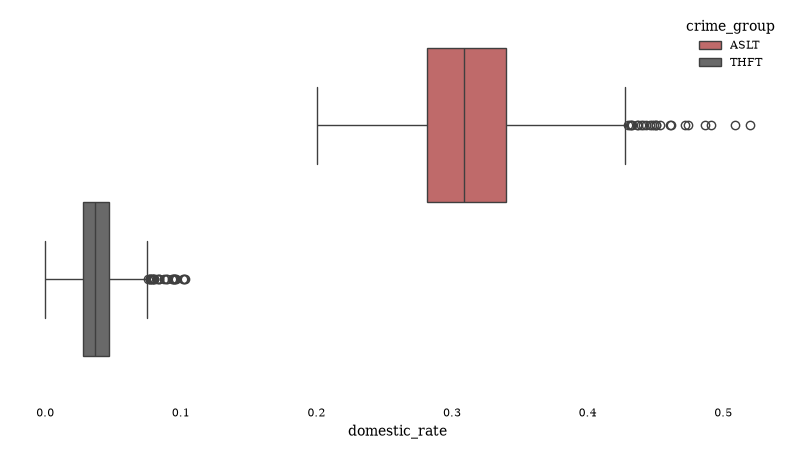

In [7]:
plt.box(False)
sns.boxplot(
    data=daily_df,
    x='domestic_rate',
    hue='crime_group',
    palette=colors
);

plt.savefig(f'{img_path}/fig08.png', dpi=300)

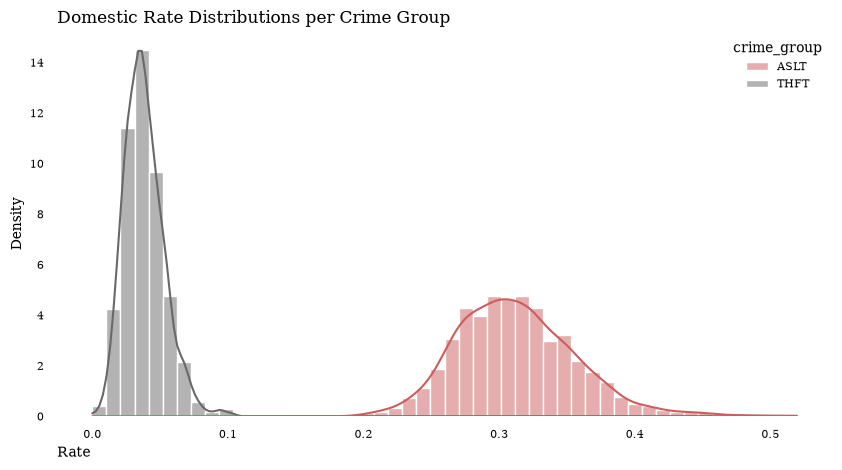

In [8]:
plt.title('Domestic Rate Distributions per Crime Group', loc='left')
plt.ylabel('Density')
plt.xlabel('Rate', loc='left')
plt.box(False)
sns.histplot(
    data=daily_df,
    x='domestic_rate',
    hue='crime_group',
    stat='density',
    kde=True,
    bins=50,
    palette=colors
);

plt.savefig(f'{img_path}/fig09.png', dpi=300)

As we have strong evidence to reject the null hypothesis, that the domestic rate daily distribution is normal, we must perform the non-parametric test: Mann-Whitney U. Its result collaborates with the graphic above, providing even stronger evidence that **the daily domestic rate for ASLT is greater than that of THFT**.

In [9]:
c = 'domestic_rate'
s_thft = daily_df.query('crime_group == "THFT"')[c].copy()
s_aslt = daily_df.query('crime_group == "ASLT"')[c].copy()

f.shapiro_test(s_thft)
print('\n')
f.shapiro_test(s_aslt)

print('\n')

f.mannwhitneyu_test(s_aslt, s_thft)

--- Shapiro-Wilk Test --- 
Statistic: 0.9711196006565259
P-value: 1.8568573975095303e-17


--- Shapiro-Wilk Test --- 
Statistic: 0.9804885467302433
P-value: 5.34760600535594e-14


---  Mann-Whitney U Test --- 
Statistic: 2598544.0
P-value: 0.0


The $\chi^2$ test evaluates whether or not there is a statistically significant dependence between variables. In our case, we consider the contingency table of **total** domestic events per crime group. The test thus checks if the difference of the resulting proportions is significant.

As a result, according to this data and test, the resulting $p$-value of 0 indicates a strong dependence between domestic rate among crime group.

Observe that, in this case, we have not tested on a daily basis, but, instead, across all data. That is, instead of comparing rates per day, we are testing whether being a THFT vs ASLT crime affects the likelihood of it being domestic or resulting in arrest.

In [13]:
df_ = df_crime.reset_index(drop=True).copy()
cont_table = pd.crosstab(df_['domestic'], df_['crime_group'])

display(cont_table)

f.chi2_test(cont_table)

crime_group,ASLT,THFT
domestic,,
0,293705,374637
1,133365,14641


--- Chi-squared Test of Independence --- 
Statistic: 103506.04156972459
P-value: 0.0


For the arrest rate, we have similar results.

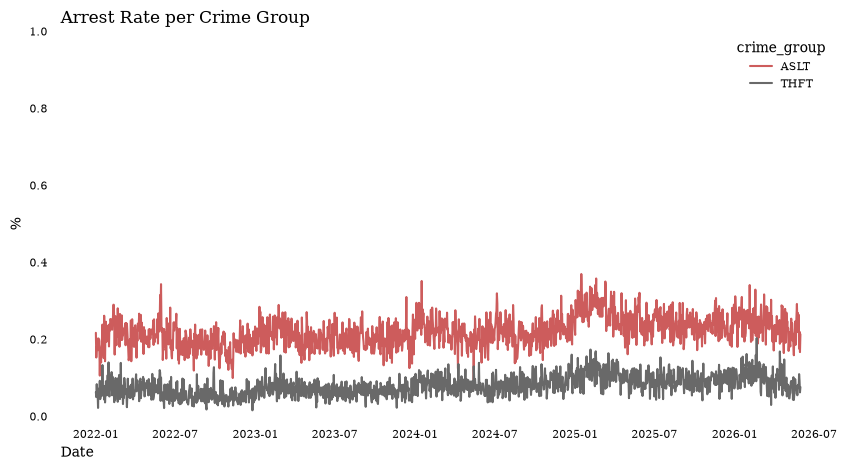

In [15]:
plt.title('Arrest Rate per Crime Group', loc='left')
plt.xlabel('Date', loc='left')
plt.ylabel('%')
plt.ylim(0, 1)
plt.box(False)
sns.lineplot(
    data=daily_df,
    x='ddate',
    y='arrest_rate',
    hue='crime_group',
    palette=colors
);

plt.savefig(f'{img_path}/fig10.png', dpi=300)

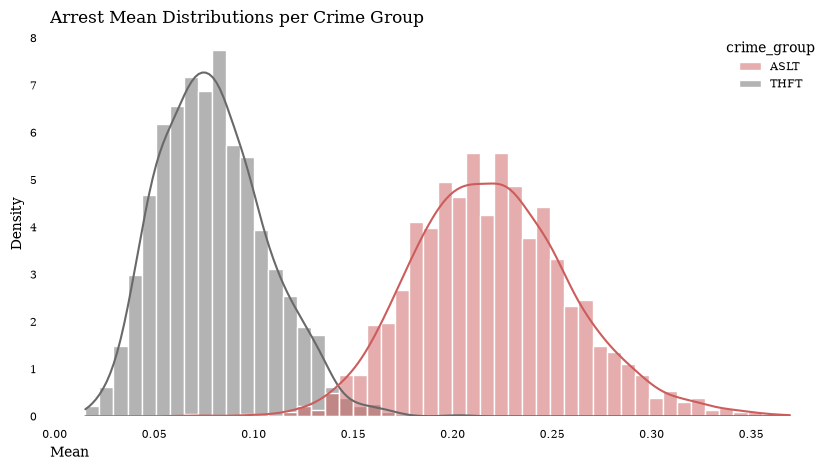

In [16]:
plt.title('Arrest Mean Distributions per Crime Group', loc='left')
plt.ylabel('Density')
plt.xlabel('Mean', loc='left')
plt.box(False)
sns.histplot(
    data=daily_df,
    x='arrest_rate',
    hue='crime_group',
    stat='density',
    kde=True,
    bins=50,
    palette=colors
);

plt.savefig(f'{img_path}/fig11.png', dpi=300)

In [17]:
c = 'arrest_rate'
s_thft = daily_df.query('crime_group == "THFT"')[c].copy()
s_aslt = daily_df.query('crime_group == "ASLT"')[c].copy()

print('THFT')
f.shapiro_test(s_thft)
print('\nASLT')
f.shapiro_test(s_aslt)

print('\n')

f.mannwhitneyu_test(s_aslt, s_thft)

THFT
--- Shapiro-Wilk Test --- 
Statistic: 0.9852268677286417
P-value: 8.481434720873352e-12

ASLT
--- Shapiro-Wilk Test --- 
Statistic: 0.9938143614758047
P-value: 2.9047887091529036e-06


---  Mann-Whitney U Test --- 
Statistic: 2594151.0
P-value: 0.0


In [18]:
df_ = df_crime.reset_index(drop=True).copy()
cont_table = pd.crosstab(df_['arrest'], df_['crime_group'])

display(cont_table)

f.chi2_test(cont_table)

crime_group,ASLT,THFT
arrest,,
0,333573,358804
1,93497,30474


--- Chi-squared Test of Independence --- 
Statistic: 31274.773063929188
P-value: 0.0


#### Hypothesis Testing: Conclusion
Therefore, the Mann-Whitney U test has shown us that the difference between crime groups is consistent day-by-day (over time), whereas the $\chi^2$ test has shown us that there is a difference overall.

Regarding our main goal, to classify districts by their criminal activity, both domestic and arrest rates can take meaningful insights, such as:

1. Domestic Rate: Proxy for Crime Severity and Social Vulnerability
    - domestic crimes can be seen as concealed crimes, since their occurrence relies indoors (hidden violence: less visible in public overall and in public data)
    - such crimes are typically more harmful, emotionally and socially, and may indicate underlying risks not being accounted for by raw counts
    - districts with a higher domestic rate may deserve a higher score, indicating that features such as *average domestic rate* may be a good candidate for separating them

2. Arrest rate: Proxy for Crime Effectiveness
    - lower arrest rates may suggest:
        - difficulty solving crimes, which may be due to lack of witness cooperation and resources
        - possible under-policing or inefficiency
        - areas where crime may persist longer (weak deterrence)
    - conversely, high arrest rates may reflect effective enforcenment, indicating that features such as *average arrest rate* may serve as an inverse risk indicator

### Crime Rate vs Crime Distance
From the scatterplot below, we see no correlation at all between `avg_crime_distance` and `arrest_rate`. Considering that both variables were calculated for a particular crime group for each day, this suggest that the outliers might be where our real interest lies. However, we have not yet considered the aggregation per district. We leave this analysis for later.

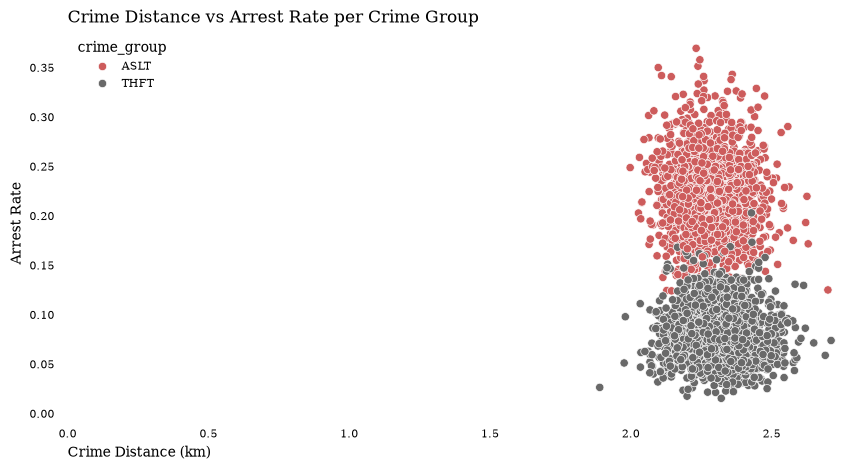

In [19]:
sns.scatterplot(
    data=daily_df,
    x='avg_dist',
    y='arrest_rate',
    hue='crime_group',
    palette=colors
)
plt.box(False)
plt.title('Crime Distance vs Arrest Rate per Crime Group', loc='left')
plt.xlabel('Crime Distance (km)', loc='left')
plt.ylabel('Arrest Rate')
plt.xlim(0);

plt.savefig(f'{img_path}/fig12.png', dpi=300)

### Hypothesis Testing 2: Number of Occurrences and Total Area Covered
**Q:** Do districts that cover larger areas have a greater number of occurrences?

In [20]:
hyp_test = df_crime[['id', 'district', 'total_cm_area']].copy()

# taking the top 50% of districts with the biggest total cm area
most_cvd_districts = grp_comm_district\
    .sort_values('total_cm_area', ascending=False)['district']\
    [:int(len(df_crime['district'].unique()) / 2) + 1]\
    .values


hyp_test = hyp_test.groupby('district')\
    .agg(
        total_crimes=('id', 'count')
    ).reset_index()

hyp_test['grp_cvd'] = hyp_test['district'].isin(most_cvd_districts)

hyp_test.head()

,district,total_crimes,grp_cvd
0,1,47541,False
1,10,34014,True
2,11,46385,False
3,12,50545,True
4,14,29326,False


In order to perform the t-test, we need to ensure that the data is normally distributed. For that, we apply Shapiro's test for each group. We obtain


| p-value | districts group |
| --- | --- |
| 43.5% | 50% top |
| 12.8% | 50% bottom |

such that we do not have suffiient evidence to reject the normality hypothesis.

In [21]:
print('50% Top Districts')
f.shapiro_test(
    hyp_test.query('grp_cvd == True')['total_crimes']
)

print('\n50% Bottom Districts')
f.shapiro_test(
    hyp_test.query('grp_cvd == False')['total_crimes']
)

50% Top Districts
--- Shapiro-Wilk Test --- 
Statistic: 0.9246130034814632
P-value: 0.3589510709654962

50% Bottom Districts
--- Shapiro-Wilk Test --- 
Statistic: 0.8977938141246604
P-value: 0.17370001286418799


#### Hypothesis Testing: Conclusion
Now for the T-test. It returns 33.6% as p-value, thus showing that **there is no statistically significant evidence that larger-area districts experience an elevated crime count**. This suggests that spatial size alone may not account for crime volume.

In [22]:
f.student_test(
    hyp_test.query('grp_cvd == True')['total_crimes'],
    hyp_test.query('grp_cvd == False')['total_crimes']
)

--- Student T-Test --- 
Statistic: 0.24144557442219533
P-value: 0.4058339886012197


### Hypothesis Testing 3: Hardship Index and Primary Types
**Q:** Is the average daily percentage of the hardship index different between ASLT and THFT?

First of all, let us understand the meaning of the hardship index. By hardship alone, we get *a condition that is difficult to endure; suffering; deprivation; oppression*, by which we conclude it must increase as measures like poverty increases and it must decrease as measures like income per capita increase. If we plot a scatterplot for these variables we can check the veracity of such claims. Hence, as ASLT encompasses more aggressive behavior, and as such, a more difficult condition to endure, it is expected the hardship index to be greater in this crime group.

By plotting `avg_hardship_index`  per `crime_group`, we note ASLT to be, in fact, greater, but it remains to be seen if such difference is statistically significant, since we have outliers from THFT in the ASLT range and vice-versa.

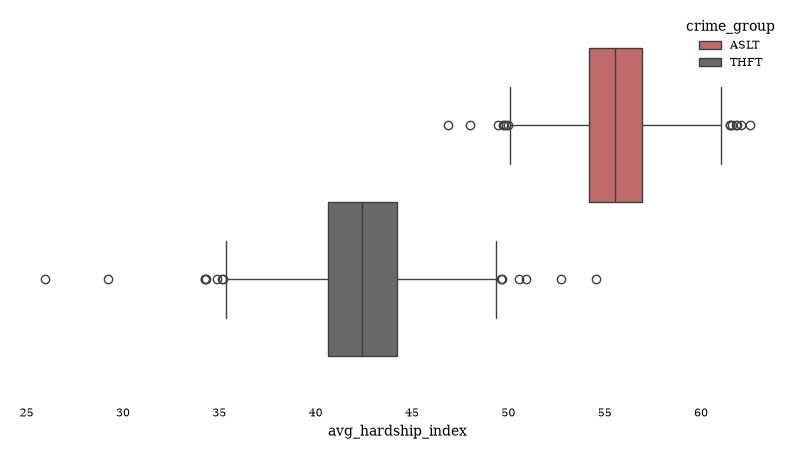

In [23]:
plt.box(False)
sns.boxplot(
    data=daily_df,
    x='avg_hardship_index',
    hue='crime_group',
    palette=colors
);

plt.savefig(f'{img_path}/fig13.png', dpi=300)

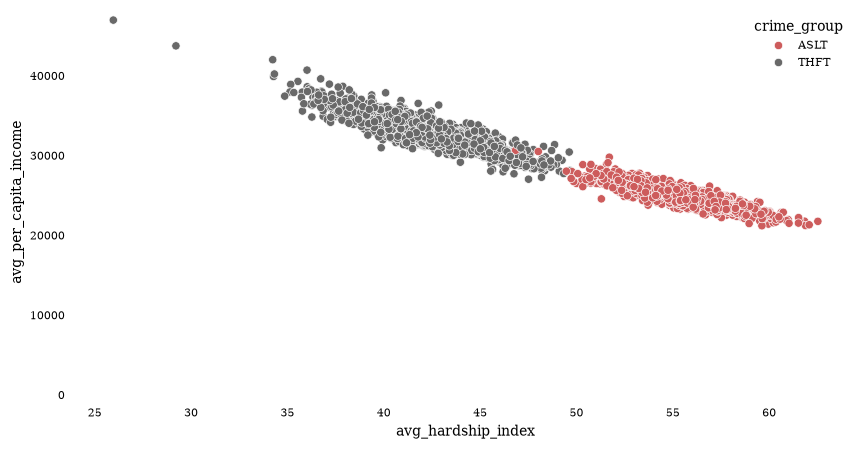

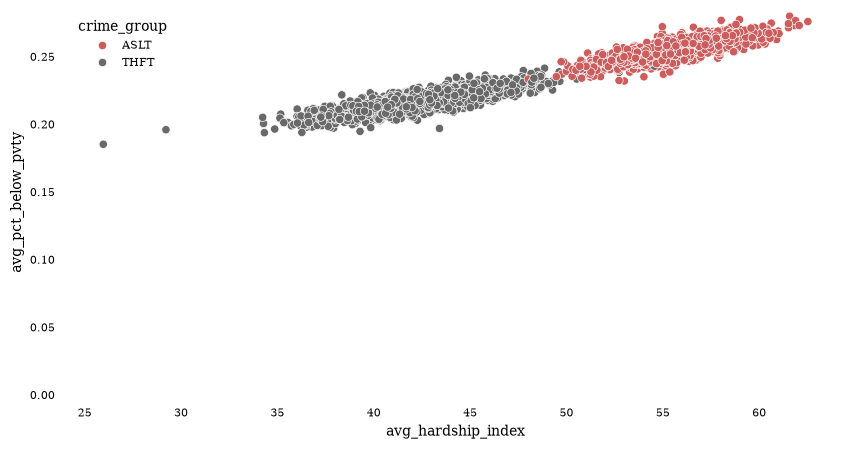

In [24]:
for c in ['avg_per_capita_income', 'avg_pct_below_pvty']:
    plt.box(False)
    sns.scatterplot(
        data=daily_df,
        x='avg_hardship_index',
        y=c,
        hue='crime_group',
        palette=colors
    );
    plt.ylim(0)

    if c == 'avg_per_capita_income':
        plt.savefig(f'{img_path}/fig14.png', dpi=300)
    else:
        plt.savefig(f'{img_path}/fig15.png', dpi=300)

    plt.show()

As we are well aware by now, we check the normality condition for `avg_hardship_index` for each group, whence we have sufficient evidence to reject the null of normality. Therefore, a non-parametric statistical teste must be perform: Mann-Whitney U test.

In [25]:
print('Shapiro Test for ASLT hardship index')
f.shapiro_test(
    daily_df.query('crime_group == "ASLT"')['avg_hardship_index']
)

print('\nShapiro Test for TFHT hardship index')
f.shapiro_test(
    daily_df.query('crime_group == "THFT"')['avg_hardship_index']
)

Shapiro Test for ASLT hardship index
--- Shapiro-Wilk Test --- 
Statistic: 0.9984018047341026
P-value: 0.13175361934381874

Shapiro Test for TFHT hardship index
--- Shapiro-Wilk Test --- 
Statistic: 0.9937396589022554
P-value: 2.5154428989719945e-06


#### Hypothesis Testing: Conclusion
The test returns a $p$-value of 0, yielding sufficient evidence to reject the null: according to our data, probably, the average hardship index, over community areas comprising the Chicago police districts, for the ASLT crime group is greater than that of THFT. This corroborates with the ideia that, not only ASLT crimes are more aggressive, but also occur in districts that cover poorer community areas, measured by the census data.

Together with Hypothesis Testing 1, we can conclude that the ASLT - THFT separation seems to be a good fit, as we observe statistically significant difference on crime counting, obtained via history of occurrences, and hardship index, obtained via census data.

In [26]:
f.mannwhitneyu_test(
    daily_df.query('crime_group == "ASLT"')['avg_hardship_index'],
    daily_df.query('crime_group == "THFT"')['avg_hardship_index']
)

---  Mann-Whitney U Test --- 
Statistic: 2597742.0
P-value: 0.0


### Census Data and Crime Rates: ASLT
Next, we evaluate crime rates and counts with the census data. We can obtain, for instance, crime and/or rate densities (counts per square km or rate per square km).

In [27]:
aslt_crime = df_crime.query('crime_group == "ASLT"').copy()

grp_aslt_district = aslt_crime\
    .groupby('district')\
    .agg(
        crime_count=('id', 'count'),
        domestic_count=('domestic', 'sum'),
        arrest_count=('arrest', 'sum'),
        domestic_rate=('domestic', 'mean'),
        arrest_rate=('arrest', 'mean'),
        avg_dist=('crime_distance', 'mean'),
        avg_cm_area=('avg_cm_area', 'mean'),
        avg_cm_len=('avg_cm_len', 'mean'),
        total_cm_area=('total_cm_area', 'mean'),
        total_cm_len=('total_cm_len', 'mean')
    )\
    .reset_index()


grp_aslt_district['crime_density'] = grp_aslt_district['crime_count'] / grp_aslt_district['total_cm_area']
grp_aslt_district['domestic_density'] = grp_aslt_district['domestic_count'] / grp_aslt_district['total_cm_area']
grp_aslt_district['arrest_density'] = grp_aslt_district['arrest_count'] / grp_aslt_district['total_cm_area']

grp_aslt_district.head()

,district,crime_count,domestic_count,arrest_count,domestic_rate,arrest_rate,avg_dist,avg_cm_area,avg_cm_len,total_cm_area,total_cm_len,crime_density,domestic_density,arrest_density
0,1,18511,2506,5030,0.135379,0.271730,1.928603,69.513587,42.997660,486.595108,300.983622,38.041895,5.150072,10.337136
1,10,22603,7252,6667,0.320842,0.294961,1.388812,129.112315,54.400566,774.673892,326.403393,29.177439,9.361358,8.606202
2,11,31851,9151,11950,0.287307,0.375184,1.938155,109.321992,47.818497,765.253943,334.729478,41.621478,11.958122,15.615731
3,12,21482,4664,3483,0.217112,0.162136,2.547215,78.080901,43.799069,780.809008,437.990695,27.512490,5.973292,4.460758
4,14,10914,2592,2093,0.237493,0.191772,1.616836,86.491201,46.489343,605.438408,325.425401,18.026607,4.281195,3.456999


Now, as the census data refers to community areas and we are grouping by district, we need to aggregate the former within the latter. We do so by averaging over the quantities.

In [28]:
district_census = df_crime[census_data + ['district']]\
    .groupby('district')\
    .agg(
        **{f'avg_{c}': (c, 'mean') for c in census_data}
    )\
    .reset_index()

aslt_census = grp_aslt_district.merge(
    district_census,
    on='district',
    how='left'
)

aslt_census.head()

,district,crime_count,domestic_count,arrest_count,domestic_rate,arrest_rate,avg_dist,avg_cm_area,avg_cm_len,total_cm_area,total_cm_len,crime_density,domestic_density,arrest_density,avg_pct_housing_crowded,avg_pct_hh_below_pvty,avg_pct_16_unemployed,avg_pct_25_without_hsd,avg_pct_dependents,avg_per_capita_income
0,1,18511,2506,5030,0.135379,0.271730,1.928603,69.513587,42.997660,486.595108,300.983622,38.041895,5.150072,10.337136,0.017827,0.162829,0.070076,0.054431,0.171897,59019.500032
1,10,22603,7252,6667,0.320842,0.294961,1.388812,129.112315,54.400566,774.673892,326.403393,29.177439,9.361358,8.606202,0.105371,0.370428,0.187026,0.388778,0.384922,11860.951696
2,11,31851,9151,11950,0.287307,0.375184,1.938155,109.321992,47.818497,765.253943,334.729478,41.621478,11.958122,15.615731,0.100262,0.380762,0.206977,0.264902,0.406345,13958.974216
3,12,21482,4664,3483,0.217112,0.162136,2.547215,78.080901,43.799069,780.809008,437.990695,27.512490,5.973292,4.460758,0.046676,0.208670,0.108068,0.160669,0.247258,38273.225007
4,14,10914,2592,2093,0.237493,0.191772,1.616836,86.491201,46.489343,605.438408,325.425401,18.026607,4.281195,3.456999,0.040586,0.173432,0.084430,0.165857,0.258613,33747.622860


#### Statistical Analysis
**Crime Density vs Poverty**

As we are analysing crime-related variables, it is interesting to assess their relation with census-like data, such as `avg_pct_hh_below_pvty`. To this end, we fit a linear regression model with `crime_density` as the dependent variable and `avg_pct_hh_below_pvty` as the independent variable. However, `crime_density` exhibits a large amplitude, ranging from 9 to 82, which is reason enough for us to apply a log transformation before the regression model.

The model thus yields as log-coefficient for the dependent variable the value 3.2854, such that, in the original scale, we end up with $\textrm{e}^{3.2854} \approx 26.72$, meaning that when the average percentage below poverty increases by 1, crime density increases approximately by 26.72. It is also worth noticing that when the average percentage goes to zero, the crime density drops to 11.35, which is to say that in a community area where there are none below the federal poverty level, there will still exist a non-zero crime density.

In [29]:
lr_log = f.run_log_model(aslt_census, 'avg_pct_hh_below_pvty', 'crime_density')
print(lr_log.summary())

                            OLS Regression Results                            
Dep. Variable:          crime_density   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.285
Method:                 Least Squares   F-statistic:                     9.380
Date:                Fri, 19 Jun 2026   Prob (F-statistic):            0.00614
Time:                        13:44:53   Log-Likelihood:                -11.531
No. Observations:                  22   AIC:                             27.06
Df Residuals:                      20   BIC:                             29.24
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     2.50

From the residual plot, we observe no relation between the fitted values and the residuals. Also, from applying Shapiro's normality test, we obtain a $p$-value of ~14%, such that we do not have sufficient evidence to reject the hypothesis that the residuals do not arise from a normal distribution. In conclusion, the residuals satisfy the model's assumptions of independency and normality of the residuals.

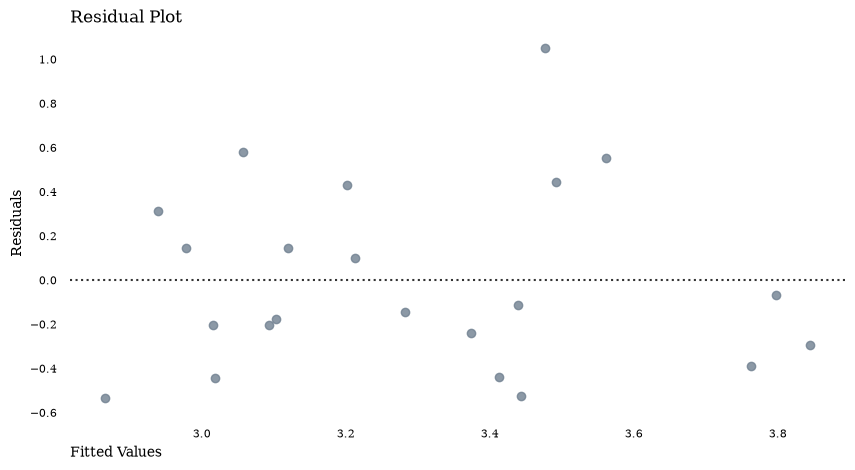

In [30]:
sns.residplot(
    x=lr_log.fittedvalues,
    y=lr_log.resid,
    color='slategrey'
)
plt.box(False)
plt.title('Residual Plot', loc='left')
plt.ylabel('Residuals')
plt.xlabel('Fitted Values', loc='left');

plt.savefig(f'{img_path}/fig16.png', dpi=300)

In [31]:
f.shapiro_test(lr_log.resid)

--- Shapiro-Wilk Test --- 
Statistic: 0.9313866308414384
P-value: 0.13113523173677263


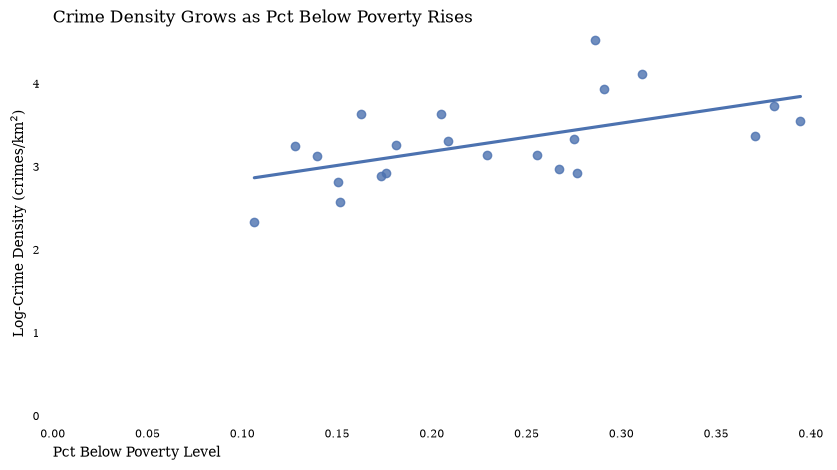

In [32]:
df_model = aslt_census.copy()
df_model['crime_density'] = np.log(df_model['crime_density'])

sns.regplot(
    data=df_model,
    x='avg_pct_hh_below_pvty',
    y='crime_density',
    ci=None
)
plt.box(False)
plt.title('Crime Density Grows as Pct Below Poverty Rises', loc='left')
plt.xlabel('Pct Below Poverty Level', loc='left')
plt.ylabel('Log-Crime Density (crimes/km$^2$)')
plt.xlim(0)
plt.ylim(0);

plt.savefig(f'{img_path}/fig17.png', dpi=300)

**Domestic Rate vs Avg Income**

When we look at the relation between `domestic_rate` and `avg_per_capita_income`, we get an inverse correlation: when the latter rises, the former decreases. That is to say that, in wealthier regions, domestic violence is lesser: an expected result. This can also be verified by that point of view of educational level, since there is an inverse relation between `avg_pct_25_without_hsd` with `avg_per_capita_income`. In this case, we see that `domestic_rate` increases as `avg_pct_25_without_hsd` increases.

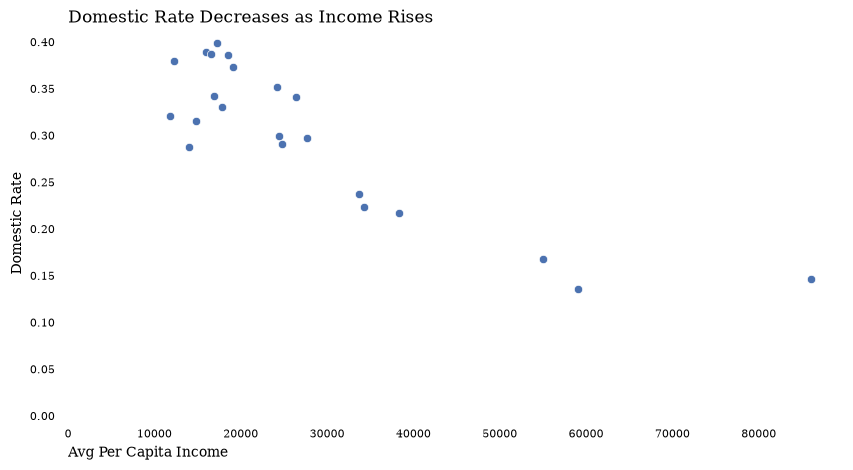

In [33]:
sns.scatterplot(
    data=aslt_census,
    x='avg_per_capita_income',
    y='domestic_rate',
)
plt.box(False)
plt.title('Domestic Rate Decreases as Income Rises', loc='left')
plt.xlabel('Avg Per Capita Income', loc='left')
plt.ylabel('Domestic Rate')
plt.xlim(0)
plt.ylim(0);

plt.savefig(f'{img_path}/fig18.png', dpi=300)

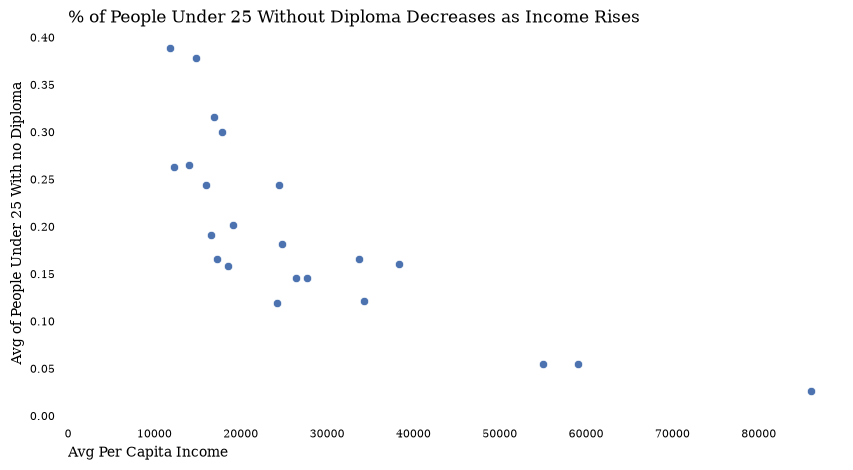

In [34]:
sns.scatterplot(
    data=aslt_census,
    x='avg_per_capita_income',
    y='avg_pct_25_without_hsd',
)
plt.box(False)
plt.title('% of People Under 25 Without Diploma Decreases as Income Rises', loc='left')
plt.xlabel('Avg Per Capita Income', loc='left')
plt.ylabel('Avg of People Under 25 With no Diploma')
plt.xlim(0)
plt.ylim(0);

plt.savefig(f'{img_path}/fig19.png', dpi=300)

### Temporal Features: ASLT
To make our analysis dynamic and time sensitive, we consider rolling statistics, like moving averages. Several time intervals (windows) were considered (7, 14, 30, 45, 90) and the only one that yields satisfying results, while maintaing its corresponding correlation matrix within $[-0.6, 0.6]$, is the 7-day window.

In [36]:
df_crime['ddate'] = df_crime.index.date

In [50]:
crime = 'ASLT'

# grouping features by district and date, for ASLT crime
# calculating total number of occurrences per district per date
# and its corresponding domestic and arrest rates
aslt_df = f.grp_features(df_crime, 'district', crime)

print('Grouping the features by district and date for ASLT crime...')
display(aslt_df.head())

print('Calculating total per average community area and crime density...')

aslt_df['avg_count_cm_area'] = aslt_df['count'] / aslt_df['avg_cm_area']          # counts per avg km2 of cm area
aslt_df['avg_drate_cm_area'] = aslt_df['domestic_rate'] / aslt_df['avg_cm_area']  # domestic rate per avg km2 of cm area
aslt_df['avg_arate_cm_area'] = aslt_df['arrest_rate'] / aslt_df['avg_cm_area']    # arrest rate per avg km2 of cm area
aslt_df['avg_crime_density'] = aslt_df['count'] / aslt_df['avg_total_cm_area']    # counts per avg total covered

aslt_df = aslt_df.drop(
    columns=['avg_cm_area', 'avg_total_cm_area']
)

display(aslt_df.head())

print('Calculating the moving averages...')
rolling_aslt7 = f.rolling_grp(aslt_df, 7)\
    .dropna(axis=0, how='any')

display(rolling_aslt7.head(10))

Grouping the features by district and date for ASLT crime...


,district,count,domestic_rate,arrest_rate,avg_dist,avg_max_dist,avg_cm_area,avg_cm_len,avg_total_cm_area,avg_total_cm_len,avg_hardship_index
ddate,,,,,,,,,,,
2022-01-01,1,11,0.454545,0.272727,1.717746,19.932010,69.513587,42.99766,486.595108,300.983622,9.545455
2022-01-02,1,7,0.285714,0.285714,1.840786,20.234275,69.513587,42.99766,486.595108,300.983622,9.857143
2022-01-03,1,4,0.000000,0.500000,2.152293,20.891473,69.513587,42.99766,486.595108,300.983622,6.000000
2022-01-04,1,5,0.400000,0.200000,1.680920,19.837512,69.513587,42.99766,486.595108,300.983622,15.000000
2022-01-05,1,5,0.000000,0.000000,1.678339,20.474176,69.513587,42.99766,486.595108,300.983622,3.800000


Calculating total per average community area and crime density...


,district,count,domestic_rate,arrest_rate,avg_dist,avg_max_dist,avg_cm_len,avg_total_cm_len,avg_hardship_index,avg_count_cm_area,avg_drate_cm_area,avg_arate_cm_area,avg_crime_density
ddate,,,,,,,,,,,,,
2022-01-01,1,11,0.454545,0.272727,1.717746,19.932010,42.99766,300.983622,9.545455,0.158242,0.006539,0.003923,0.022606
2022-01-02,1,7,0.285714,0.285714,1.840786,20.234275,42.99766,300.983622,9.857143,0.100700,0.004110,0.004110,0.014386
2022-01-03,1,4,0.000000,0.500000,2.152293,20.891473,42.99766,300.983622,6.000000,0.057543,0.000000,0.007193,0.008220
2022-01-04,1,5,0.400000,0.200000,1.680920,19.837512,42.99766,300.983622,15.000000,0.071928,0.005754,0.002877,0.010275
2022-01-05,1,5,0.000000,0.000000,1.678339,20.474176,42.99766,300.983622,3.800000,0.071928,0.000000,0.000000,0.010275


Calculating the moving averages...


,district,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgDist7,ASLT_RollAvgMaxDist7,ASLT_RollAvgCMLen7,ASLT_RollAvgLen7,ASLT_RollAvgHardship7,ASLT_RollAvgCountCMArea7,ASLT_RollAvgDRateCMArea7,ASLT_RollAvgARateCMArea7,ASLT_RollAvgDensity7
ddate,,,,,,,,,,,,,
2022-01-07,24,5.285714,0.293651,0.214286,1.713848,35.387097,37.256894,186.284470,41.198413,0.077781,0.004321,0.003153,0.015556
2022-01-07,12,6.857143,0.335793,0.146507,2.484215,21.287635,43.799069,437.990695,33.493734,0.087821,0.004301,0.001876,0.008782
2022-01-07,22,5.571429,0.404422,0.236395,2.754716,32.274564,48.763518,390.108148,38.385034,0.055021,0.003994,0.002335,0.006878
2022-01-07,7,12.428571,0.397576,0.187977,1.698811,25.040365,44.442936,311.100550,87.822477,0.129360,0.004138,0.001957,0.018480
2022-01-07,6,14.857143,0.510369,0.093152,2.142886,28.451400,42.850458,514.205491,65.981803,0.172809,0.005936,0.001083,0.014401
2022-01-07,2,11.142857,0.410853,0.068709,2.375051,22.169884,30.657808,306.578082,50.732989,0.265868,0.009803,0.001639,0.026587
2022-01-07,16,3.857143,0.333333,0.297619,4.057896,35.192340,57.936229,695.234748,27.928571,0.037227,0.003217,0.002872,0.003102
2022-01-07,1,6.571429,0.198609,0.222635,1.969116,20.446927,42.997660,300.983622,8.400371,0.094534,0.002857,0.003203,0.013505
2022-01-07,18,5.857143,0.252721,0.250794,1.417469,23.803756,50.603500,303.620999,1.196995,0.058822,0.002538,0.002519,0.009804


### Training and OOT Samples

In [51]:
# training sample: data before 2026
train_aslt = rolling_aslt7.loc[:'2025'].copy()

# out of time sample: data from 2026 onward
oot_aslt = rolling_aslt7.loc['2026'].copy()

In [54]:
train_aslt.to_csv(f'{gld_path}/train_aslt.csv', index=True)
oot_aslt.to_csv(f'{gld_path}/oot_aslt.csv', index=True)

#### Features

In [55]:
train_aslt = pd.read_csv(
    f'{gld_path}/train_aslt.csv',
    index_col='ddate',
    parse_dates=True
)
oot_aslt = pd.read_csv(
    f'{gld_path}/oot_aslt.csv',
    index_col='ddate',
    parse_dates=True
)

In [71]:
grp = 'ASLT'
grp_features = [
    f'{grp}_RollAvg7',
    f'{grp}_RollDRate7',
    f'{grp}_RollARate7',
    f'{grp}_RollAvgDist7',
    f'{grp}_RollAvgMaxDist7',
    f'{grp}_RollAvgDensity7'
]
cm_features = [
    f'{grp}_RollAvgCMLen7',
    f'{grp}_RollAvgLen7',
    f'{grp}_RollAvgHardship7',
    f'{grp}_RollAvgCountCMArea7',
    f'{grp}_RollAvgDRateCMArea7',
    f'{grp}_RollAvgARateCMArea7'
]
features_list = grp_features + cm_features


features_raw_aslt = train_aslt[features_list].reset_index(drop=True).copy()
features_aslt = features_raw_aslt.dropna().reset_index(drop=True).copy()

features_aslt.head()

,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgDist7,ASLT_RollAvgMaxDist7,ASLT_RollAvgDensity7,ASLT_RollAvgCMLen7,ASLT_RollAvgLen7,ASLT_RollAvgHardship7,ASLT_RollAvgCountCMArea7,ASLT_RollAvgDRateCMArea7,ASLT_RollAvgARateCMArea7
0,5.285714,0.293651,0.214286,1.713848,35.387097,0.015556,37.256894,186.284470,41.198413,0.077781,0.004321,0.003153
1,6.857143,0.335793,0.146507,2.484215,21.287635,0.008782,43.799069,437.990695,33.493734,0.087821,0.004301,0.001876
2,5.571429,0.404422,0.236395,2.754716,32.274564,0.006878,48.763518,390.108148,38.385034,0.055021,0.003994,0.002335
3,12.428571,0.397576,0.187977,1.698811,25.040365,0.018480,44.442936,311.100550,87.822477,0.129360,0.004138,0.001957
4,14.857143,0.510369,0.093152,2.142886,28.451400,0.014401,42.850458,514.205491,65.981803,0.172809,0.005936,0.001083


Anaylising the `features_aslt` dataset, we observe small correlation between the variables. Regarding its distributions, we see, via the histogram-boxplot figure, that

- `ASLT_RollAvg7` is bimodal and centered around 15, showing that a typical district sees around 15 occurrences in a 7 day window, with outliers above 30, indicating highly aggressive district(s) (crime surges?)
- `ASLT_RollDRate7` is modal and centered around 0.3, meaning that, for a typical district, 30% of its occurrences in a 7 day window are domestic,  with outliers below 0.05 and above 0.6
- `ASLT_RollARate7` is modal and centered around 0.2, indicanting that, for a typical district, 20% of its occurrences in a 7 day window result in arrest, with outliers below 0.02 and above 0.4
- `ASLT_RollAvgDist7` is modal and centered around 2, showing that crimes occur, in a typical district in a 7 day window, around 2 km from its corresponding police station, with outliers above 4
- `ASLT_RollMaxDist7` exhibits six modes with its median around 26, meaning that crimes occur, in a typical district in a 7 day window, at most at 26 km from its corresponding police station, with no outliers

Individually, we note the distributions to be reasonably stable, but with meaningful outliers deserving further investigation so as to review policing in some areas/events. For instance, the outliers for `ASLT_RollAvg7` can be gang-related; the outliers for `ASLT_RollDRate7` may suggest zones/events with social/environmental issues, whereas the outliers for `ASLT_RollARate7`, showing areas with practically no arrests and others with high enforcement, may indicate a review in police displacement/action.

Conversely, we observe a weak correlation between the number of occurrences and the domestic rate, for the same period, suggesting no more than the expected behavior: more domestic occurrences = more occurrences. More importantly, the virtually zero correlation between `ASLT_RollAvg7` and `ASLT_RollARate7` implies that the arrest rate does not escalate accordingly, such that police action is not scaling with risk. Additionally, the inverse correlation between `ASLT_RollDRate7` and `ASLT_RollARate7`, albeit virtually zero as well, indicates that domestic violence does not result in arrests.

Also, we highlight the expected inverse correlation between `arrest_rate` and the distance variables, showing that the farther from the police station the crime occurs, less likely will it result in an arrest, and, finally, the positive correlation between `domestic_rate` with the latter, indicating greater domestic rates for greater distances.

When regarding the community areas features, we observe high correlations between some of them. Therefore, we choose to drop `ASLT_RollAvgLen7`.

In [72]:
print('Pearson correlation:')
display(features_aslt.corr(method='pearson'))

features_aslt = features_aslt.drop(
    columns=['ASLT_RollAvgLen7']
)

Pearson correlation:


,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgDist7,ASLT_RollAvgMaxDist7,ASLT_RollAvgDensity7,ASLT_RollAvgCMLen7,ASLT_RollAvgLen7,ASLT_RollAvgHardship7,ASLT_RollAvgCountCMArea7,ASLT_RollAvgDRateCMArea7,ASLT_RollAvgARateCMArea7
ASLT_RollAvg7,1.000000,0.260213,0.161532,0.083686,-0.365269,0.375677,-0.038025,0.155890,0.584958,0.718879,0.129552,0.034083
ASLT_RollDRate7,0.260213,1.000000,-0.076247,0.184491,0.194577,0.169364,0.115689,0.094684,0.624688,0.130354,0.643320,-0.193730
ASLT_RollARate7,0.161532,-0.076247,1.000000,-0.194109,-0.246066,0.159894,0.260594,-0.173060,0.197046,-0.088091,-0.257032,0.673515
ASLT_RollAvgDist7,0.083686,0.184491,-0.194109,1.000000,0.288475,-0.402456,-0.062536,0.772836,0.047821,0.113486,0.164226,-0.115224
ASLT_RollAvgMaxDist7,-0.365269,0.194577,-0.246066,0.288475,1.000000,-0.310240,0.047189,0.188869,-0.198442,-0.381081,0.046605,-0.261080
ASLT_RollAvgDensity7,0.375677,0.169364,0.159894,-0.402456,-0.310240,1.000000,0.338264,-0.671510,0.280328,0.304060,0.082025,0.051343
ASLT_RollAvgCMLen7,-0.038025,0.115689,0.260594,-0.062536,0.047189,0.338264,1.000000,-0.148605,0.130298,-0.560258,-0.549134,-0.408450
ASLT_RollAvgLen7,0.155890,0.094684,-0.173060,0.772836,0.188869,-0.671510,-0.148605,1.000000,0.045487,0.109288,0.057984,-0.139885
ASLT_RollAvgHardship7,0.584958,0.624688,0.197046,0.047821,-0.198442,0.280328,0.130298,0.045487,1.000000,0.265944,0.268733,-0.086888
ASLT_RollAvgCountCMArea7,0.718879,0.130354,-0.088091,0.113486,-0.381081,0.304060,-0.560258,0.109288,0.265944,1.000000,0.555903,0.325789


When looking at the outliers, we disregard `cm_features` as they do not reflect occurrences data.

In [73]:
features_outliers = features_aslt[grp_features].copy()

s = 1.5
q1 = features_outliers.quantile(0.25)
q3 = features_outliers.quantile(0.75)
iqr = q3 - q1

iqr_lower = q1 - s * iqr
iqr_upper = q3 + s * iqr

outliers = (
    (features_outliers < iqr_lower) | (features_outliers > iqr_upper)
).any(axis=1)

iqr

ASLT_RollAvg7           6.714286
ASLT_RollDRate7         0.139291
ASLT_RollARate7         0.098408
ASLT_RollAvgDist7       0.949365
ASLT_RollAvgMaxDist7    8.622268
ASLT_RollAvgDensity7    0.010774
dtype: float64

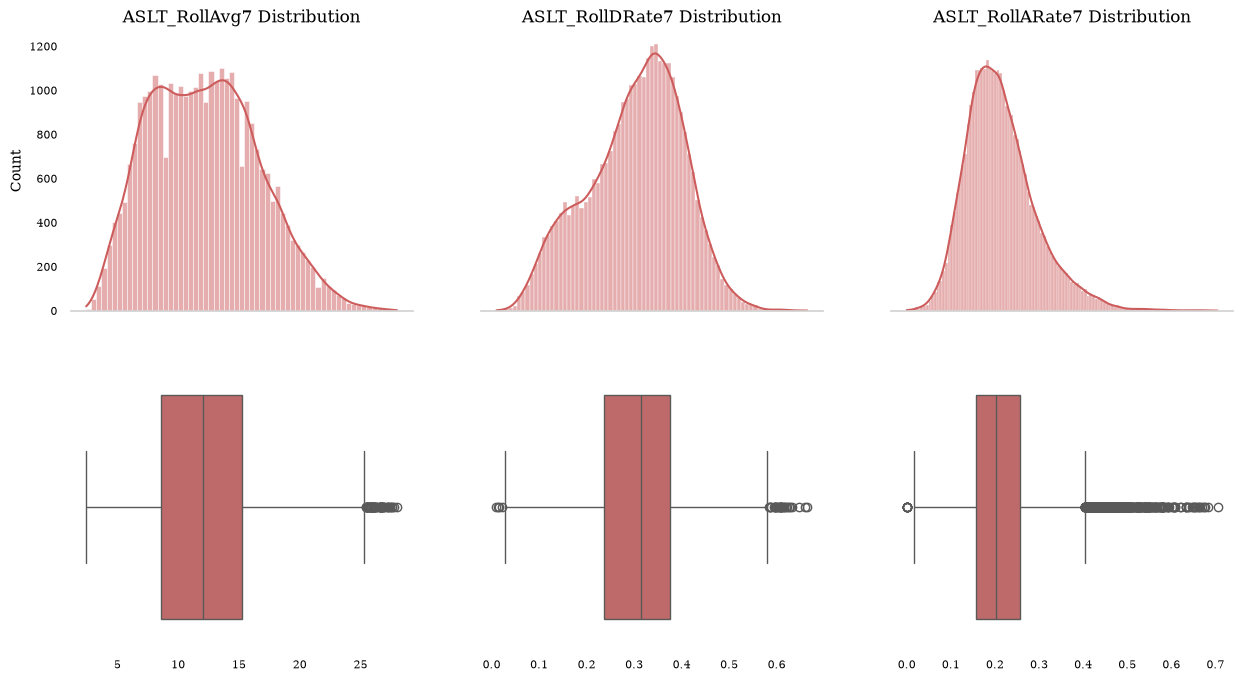

In [60]:
f.gen_paired_hist_box(
    features_aslt[[
        f'{grp}_RollAvg7',
        f'{grp}_RollDRate7',
        f'{grp}_RollARate7',
    ]]
)

plt.savefig(f'{img_path}/fig20.png', dpi=300)

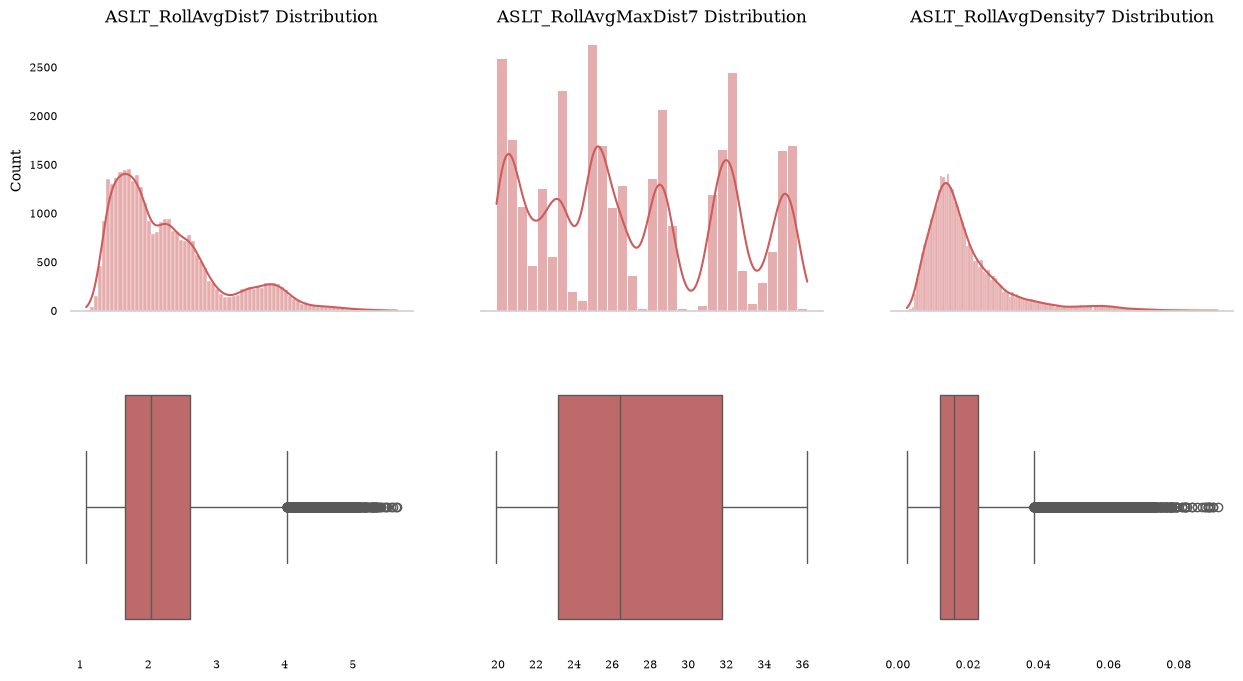

In [61]:
f.gen_paired_hist_box(
    features_aslt[[
        f'{grp}_RollAvgDist7',
        f'{grp}_RollAvgMaxDist7',
        f'{grp}_RollAvgDensity7',
    ]]
)

plt.savefig(f'{img_path}/fig21.png', dpi=300)

#### Outliers: ASLT
Before going into Machine Learning, caution is adivsed when concerning outliers, since it may compromise the model's performance or even mislead one's interpretation. In our case, it seems unlikely that the outliers arise from errors or low data quality, falling best on the rare occurrences category.

By selecting them onto our dataset, we can analyse them via two interesting point of views: by `date` and by `district`, so as to associate the outliers due to some time or zone event. For instance, when looking at the `date` point of view, where we count the number of districts that are being referred to as outliers in a given date, we observe entries with at most 5 districts, suggesting notorious time periods. Particularly, we emphasize the start of every year.

In [84]:
train_aslt.reset_index()

,ddate,district,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgDist7,ASLT_RollAvgMaxDist7,ASLT_RollAvgCMLen7,ASLT_RollAvgLen7,ASLT_RollAvgHardship7,ASLT_RollAvgCountCMArea7,ASLT_RollAvgDRateCMArea7,ASLT_RollAvgARateCMArea7,ASLT_RollAvgDensity7
0,2022-01-07,24,5.285714,0.293651,0.214286,1.713848,35.387097,37.256894,186.284470,41.198413,0.077781,0.004321,0.003153,0.015556
1,2022-01-07,12,6.857143,0.335793,0.146507,2.484215,21.287635,43.799069,437.990695,33.493734,0.087821,0.004301,0.001876,0.008782
2,2022-01-07,22,5.571429,0.404422,0.236395,2.754716,32.274564,48.763518,390.108148,38.385034,0.055021,0.003994,0.002335,0.006878
3,2022-01-07,7,12.428571,0.397576,0.187977,1.698811,25.040365,44.442936,311.100550,87.822477,0.129360,0.004138,0.001957,0.018480
4,2022-01-07,6,14.857143,0.510369,0.093152,2.142886,28.451400,42.850458,514.205491,65.981803,0.172809,0.005936,0.001083,0.014401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31961,2025-12-31,11,13.857143,0.330470,0.331181,2.026571,23.216825,47.818497,334.729478,83.417954,0.126755,0.003023,0.003029,0.018108
31962,2025-12-31,3,11.714286,0.360495,0.202731,1.931557,26.827876,41.011801,246.070804,58.894356,0.170757,0.005255,0.002955,0.028459
31963,2025-12-31,2,18.428571,0.398440,0.134699,2.270110,22.604598,30.657808,306.578082,53.631512,0.439705,0.009507,0.003214,0.043970
31964,2025-12-31,15,8.571429,0.425911,0.380342,1.400444,25.394339,75.226475,75.226475,73.000000,0.043018,0.002138,0.001909,0.043018


In [86]:
out_index = features_aslt[outliers].index
train_ = train_aslt.reset_index()

out_df = train_[train_.index.isin(out_index)].copy()

# analysing per date: days showing occurrences in at least 4 districts
# (> 10% the total number of districts)
out_df_date = out_df[['ddate', 'district']]\
    .groupby('ddate')\
    .agg(count=('district', 'count'))\
    .reset_index()
out_df_date.query('count > 3').head(50)

,ddate,count
17,2022-01-25,4
18,2022-01-26,5
20,2022-01-28,4
21,2022-01-29,4
22,2022-01-30,5
25,2022-02-02,4
26,2022-02-03,4
28,2022-02-05,4
29,2022-02-06,4
34,2022-02-11,4


From the district-day analysis, we are able to observe hot districts, facing occurrences in at most 1073 days, being an average close to 3 occurrences per day.

In [87]:
# analysing per district: district showing occurrences in at least 50 days
out_df_district = out_df[['ddate', 'district']]\
    .groupby('district')\
    .agg(count=('ddate', 'count'))\
    .reset_index()

out_df_district.query('count > 50')

,district,count
1,2,152
2,3,637
3,4,200
9,10,117
10,11,501
12,15,1427
13,16,840
